# About
Dieses Jupiternotebook betrifft das Coding für die TechLabs Münster Journey im SoSe 2026 von Gruppe 2 im Deep Learning Track.
## Thema: Erkennen von Baumarten in Münster anhand von Luftbildern
Ein visuelles Maschine Learning Model soll im Rahmen des supervised learnings mit Luftbildern von Münster darauf trainiert werden, Baumarten zu erkennen. Die Labels stammen aus dem Baumkataster der Stadt Münster (dort sind Label mit Geo-Koordinaten in einer Tabelle hinterlegt); die Luftbilder (sogenannte Orthophotos im Format GEO TIFF) aus dem opendata-Portal tim-online des Landes NRW.
## Vorgehen
- Die Label aus dem Baumkataster müssen mit den visuellen Daten der Luftbilder gematcht werden. Als gemeinsamer key fungieren dabei die Geo-Koordinaten.
- Das Baumkataster enhält nur Punktdaten für jeden verzeichneten Baum. Da in den Luftbilddaten flächige Bildinformation genutzt werden soll, muss jedem Standort eines Baumes eine Fläche um diese Punktkoordinate zugeordnet werden.
  - ein pragmatischer Ansatz kann darin bestehen, eine Fläche von 10m x 10m um einen Baum als zu diesem Baum gehörige Fläche im Luftbild zu definieren.
  - ein informierterer Ansatz kann darin bestehen, dass für jede Baumart exemplarisch überprüft wird, wie groß die geografische bzw. Pixelfläche in den Luftbildern typischerweisen sein sollte.
- Im Ergebnis entseht also ein GEO JSON bzw. GEO PANDAS Objekt, dass sowohl die gerasterten/ georeferenzierten Flächen mit ihren Bildinformationen (RGBI-Werte jeweils für die zu einer Baumfläche gehörigen Pixel) als auch die Labels enthält.
- Ein so aufbereiteter Datensatz ist Input für das Training eines Modells.
## Modell 'Faster R-CNN'

https://medium.com/@RobuRishabh/understanding-and-implementing-faster-r-cnn-248f7b25ff96
(...)

## Datenquellen (Zugriff)

Datensets bereitgestellt auf Moritz' Kaggle: https://www.kaggle.com/datasets/datamor/geo-tiffs-nrw-mnster
Nachfolgend die Pfade zu den Originalquellen.

### Baumkataster der Stadt Münster:
https://opendata.stadt-muenster.de/dataset/digitales-baumkataster-m%C3%BCnster/resource/53c9f6f3-ca4b-4418-b551-52d0e6b1b020
(csv-Datei; alternativ GEOJSON)

Datenstruktur (hat 43.115 Zeilen):

| WKN                                     | str_sch | baumgruppe |
| :-------------------------------------- | :----- | :--------- |
| POINT (7.61234661409564 51.9746341864951) | 2505 | Carpinius  |

### GEO TIFFs NRW
neben dem Geoportal NRW gibt's zum selben Datenbestand das Portal --> https://www.tim-online.nrw.de/tim-online2/
- in oberer Leiste 'Download' klicken öffnet Editor
- 1. Schritt 'Produkt': Luftbild auswählen und dann verfeinern zu Orthophotos
- 2. Datenfortmat: GEO TIFF
- 3. Ort selektieren (--> Stadt Münster hat mehrere Kacheln)
- 4. Herunterladen (jede Kachel gleich 1 Datei)

Kennzeichen:
- Ein Pixel entspricht einem Raster von 1dmx1dm
- Lage / Lageangabe: ETRS89/UTM32 (EPSG 25832)

Dann der eigenen Arbeitumgebung zugänglich machen, z.B. bei Arbeit mit Colab in Google Drive-Ordner gemeinsam mit dem Jupiter Notebook ablegen.

Über die Luftbilddienste für NRW:
https://www.bezreg-koeln.nrw.de/geobasis-nrw/produkte-und-dienste/luftbild-und-satellitenbildinformationen/aktuelle-luftbild-und

### Satellitenbilder (optional)
Aus dem Erdbeobachtungsprogramm der ESA und der EU, Corpernicus, liegen durch die sogenannten Sentinel-Missionen Erdbeobachtungsdaten vor:
https://gdz.bkg.bund.de/index.php/default/webdienste/digitale-orthophotos.html

## CODING-Abschnitt

### Mounting Google Drive

For larger files or persistent storage, you can mount your Google Drive directly. This allows you to access files stored in your Drive account.

In [ ]:
# mounting google drive
from google.colab import drive
drive.mount('/content/drive')

# Now you can access files in your Drive, for example:
# df_drive = pd.read_csv('/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/your_file.csv')
# display(df_drive.head())

Mounted at /content/drive


### Baumkataster importieren und visualieren
Mit der Python-Bibliothek Geopandas wird ein Geo Data Frame erzeugt, dessen Geo-Koordinaten verarbeitet werden können.
Mit der Bibliothek Folium werden die Standorte und Label der Böume auf einer Basemap visualisiert.

In [ ]:
# Install geopandas if you haven't already
!pip install geopandas

import geopandas

# IMPORTANT: Make sure your Google Drive is mounted. If not, uncomment and run the cell below:
# from google.colab import drive
# drive.mount('/content/drive')

# Define the path to your GeoJSON file in Google Drive
# Replace 'your_folder/your_geojson_file.geojson' with the actual path to your file
geoj_file_path = '/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/gruen_opendata.geojson' # Example path

# Read the GeoJSON file into a GeoDataFrame
try:
    gdf = geopandas.read_file(geoj_file_path)
    print("GeoJSON file loaded successfully!")
    display(gdf.head())
except Exception as e:
    print(f"Error loading GeoJSON file: {e}")
    print("Please ensure the path is correct and your Google Drive is mounted.")

GeoJSON file loaded successfully!


,str_schl,baumgruppe,geometry
0,02505,Tilia,POINT (7.61235 51.97463)
1,02505,Tilia,POINT (7.61254 51.97467)
2,02505,Carpinus,POINT (7.61242 51.97601)
3,02505,Carpinus,POINT (7.61241 51.9761)
4,02505,Carpinus,POINT (7.61239 51.97637)


#### Label des Baumkatasters auf Karte visualisieren
Mit der Bibliothek Folium wird eine zoombare Karte erstellt und auf dieser werden die Positionen und zugehörigen Labels der Bäume dargestellt.

In [ ]:
# Install folium if you haven't already
!pip install folium

import folium
from folium.plugins import MarkerCluster

# Reproject gdf to WGS84 (latitude/longitude) if it's not already, as folium expects this CRS
# The current CRS is ETRS89/UTM32 (EPSG 25832) which is projected, so we need to transform it.
if gdf.crs != 'EPSG:4326':
    gdf_wgs84 = gdf.to_crs('EPSG:4326')
else:
    gdf_wgs84 = gdf.copy()

# Get the centroid of the data to center the map.
# This uses the mean of the latitude and longitude of all points.
map_center_lat = gdf_wgs84.geometry.y.mean()
map_center_lon = gdf_wgs84.geometry.x.mean()

# Create a folium map centered on Münster
m = folium.Map(location=[map_center_lat, map_center_lon], zoom_start=12)

# Create a MarkerCluster object to handle a large number of markers
marker_cluster = MarkerCluster().add_to(m)

# Add each tree location to the MarkerCluster
for idx, row in gdf_wgs84.iterrows():
    # Get latitude and longitude from the point geometry
    lat, lon = row.geometry.y, row.geometry.x

    # Create a popup with the 'baumgruppe' label
    popup_text = f"Baumgruppe: {row['baumgruppe']}"

    # Add a marker to the marker cluster
    folium.Marker(
        location=[lat, lon],
        popup=popup_text,
        tooltip=row['baumgruppe'] # Tooltip shows on hover
    ).add_to(marker_cluster)

# Display the map
m

Output hidden; open in https://colab.research.google.com to view.

**Reasoning**:
Save the Folium map object `m` to an HTML file in the specified drive path, allowing for easy sharing and viewing.



In [ ]:
output_map_path = os.path.join(drive_path, 'tree_locations_map.html')
m.save(output_map_path)

print(f"Interactive map saved to: {output_map_path}")

Interactive map saved to: /content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/tree_locations_map.html


#### Baumkataster statistisch explorieren

GeoJSON file loaded successfully within this cell.
### Baumgruppe Counts and Percentages ###


,Count,Percentage
baumgruppe,,
Tilia,10279,23.841444
Quercus,8199,19.017025
Acer,5324,12.348657
Carpinus,3448,7.997402
Baum Amt62,2832,6.568632
...,...,...
Sambucus,1,0.002319
Decaisnea,1,0.002319
Pseudotsuga,1,0.002319


/tmp/ipykernel_4482/4007488410.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=baumgruppe_summary.head(20).index, y=baumgruppe_summary.head(20)['Count'], palette='viridis')


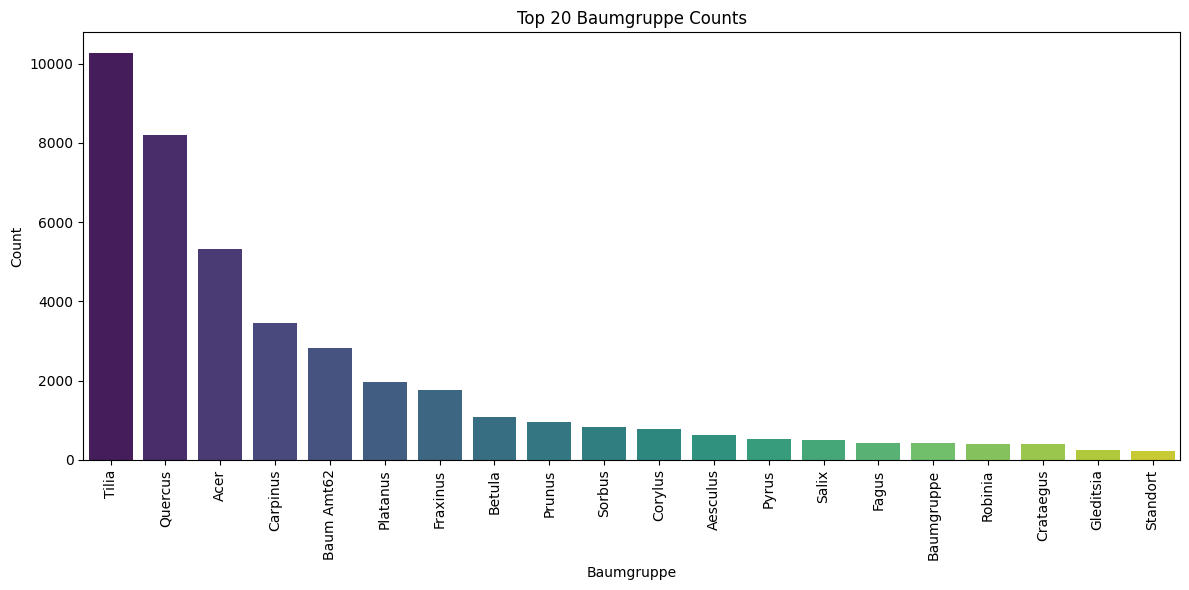


### Top 5 Baumgruppe per Street Code (str_schl) ###


/tmp/ipykernel_4482/4007488410.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top_5_per_street = top_baumgruppe_per_street_df.groupby('str_schl').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)


,str_schl,baumgruppe,count
0,,Baum Amt62,6
1,,Acer,2
2,,Malus-Hybride,2
3,,Carpinus,1
4,,Quercus,1
...,...,...,...
3236,07495,,3
3237,07495,Carpinus,1
3238,08701,Quercus,1
3239,09510,Castanea,1


/tmp/ipykernel_4482/4007488410.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')


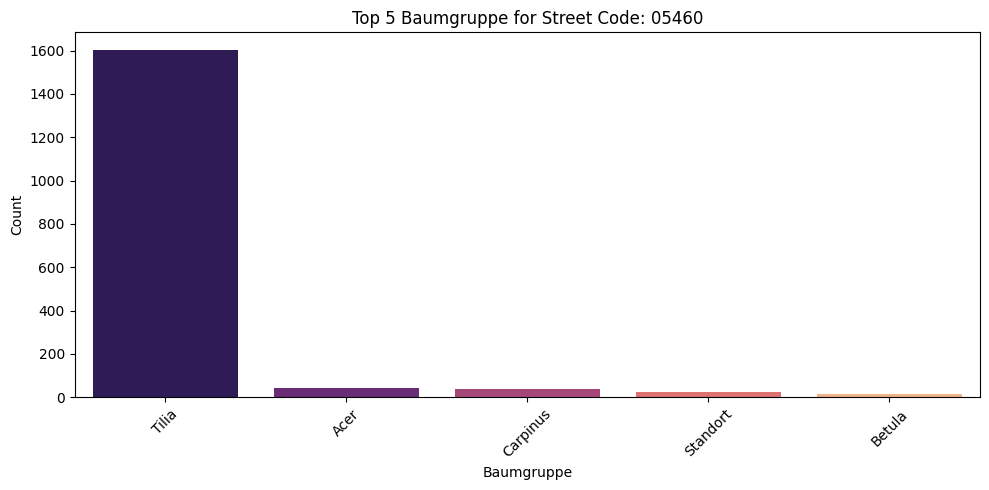

/tmp/ipykernel_4482/4007488410.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')


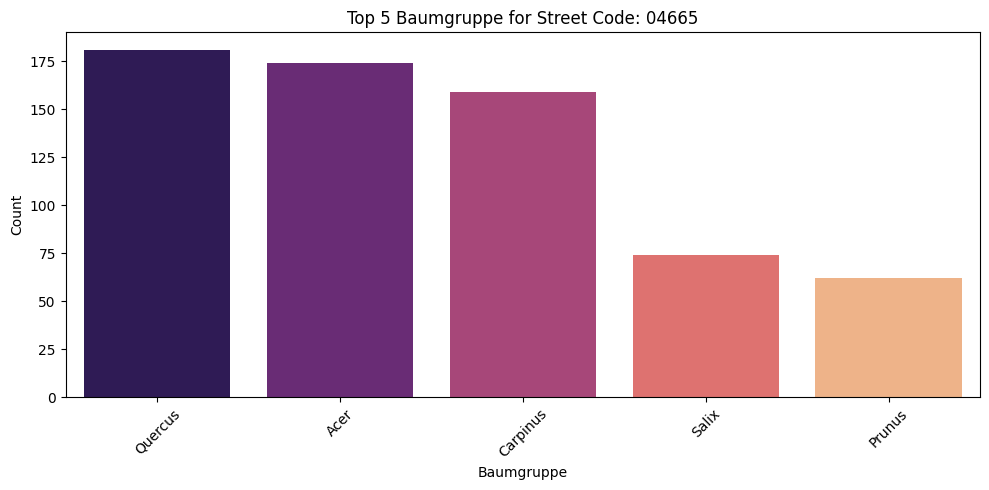

/tmp/ipykernel_4482/4007488410.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')


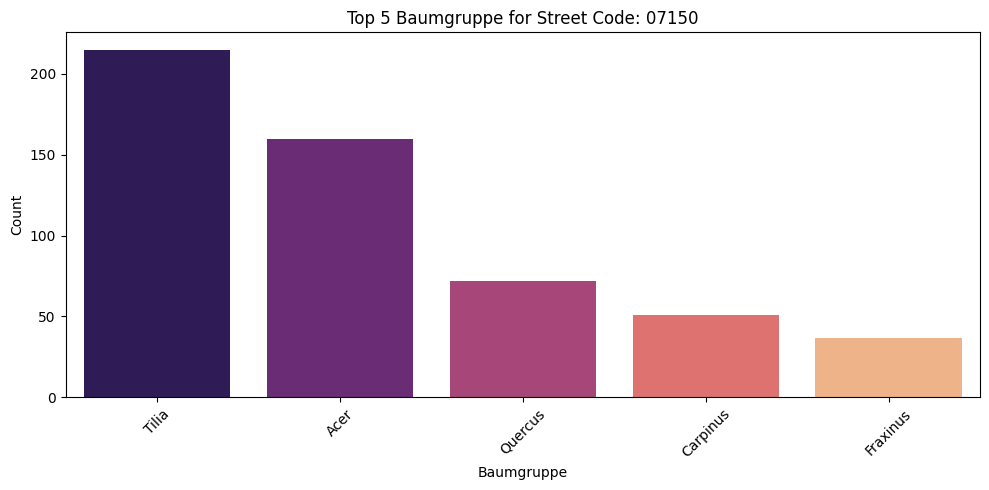

/tmp/ipykernel_4482/4007488410.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')


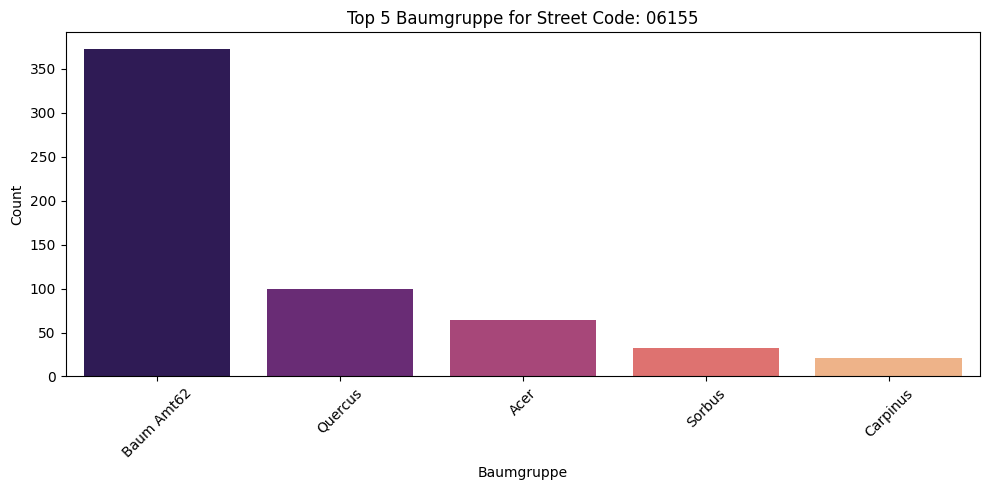

/tmp/ipykernel_4482/4007488410.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')


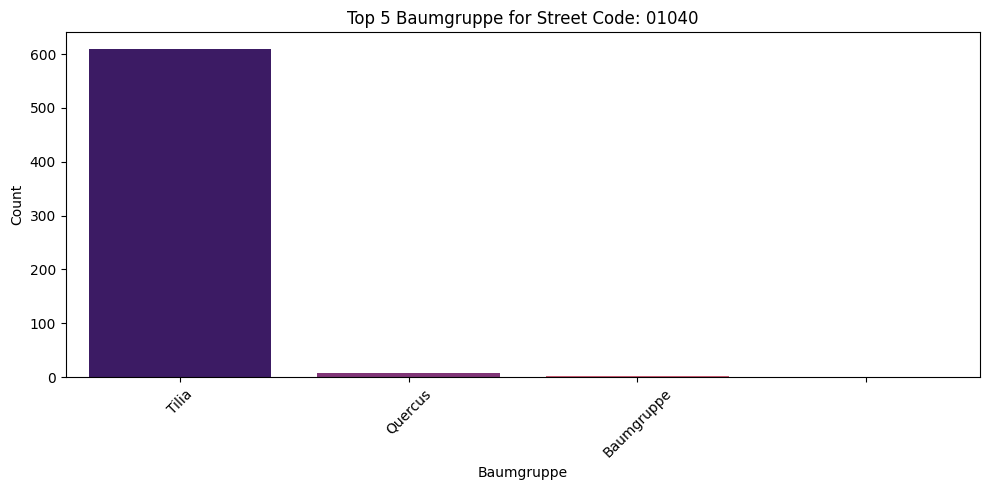

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas # Added to ensure geopandas is available

# Re-load gdf to ensure it's defined in this execution context
# Make sure to set the correct path to your GeoJSON file
geoj_file_path = '/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/gruen_opendata.geojson' # Example path, please verify
try:
    gdf = geopandas.read_file(geoj_file_path)
    print("GeoJSON file loaded successfully within this cell.")
except Exception as e:
    print(f"Error loading GeoJSON file: {e}")
    print("Please ensure the path is correct and your Google Drive is mounted.")
    # If gdf cannot be loaded, stop execution here to prevent further errors
    raise

# 1. Count and percentage of each label in 'baumgruppe'
print("### Baumgruppe Counts and Percentages ###")
baumgruppe_counts = gdf['baumgruppe'].value_counts()
baumgruppe_percentages = gdf['baumgruppe'].value_counts(normalize=True) * 100

baumgruppe_summary = pd.DataFrame({
    'Count': baumgruppe_counts,
    'Percentage': baumgruppe_percentages
}).sort_values(by='Count', ascending=False)

display(baumgruppe_summary)

# Optional: Plotting top N baumgruppe counts
plt.figure(figsize=(12, 6))
sns.barplot(x=baumgruppe_summary.head(20).index, y=baumgruppe_summary.head(20)['Count'], palette='viridis')
plt.title('Top 20 Baumgruppe Counts')
plt.xlabel('Baumgruppe')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 2. Top five most tree labels ('baumgruppe') for every street code ('str_schl')
print("\n### Top 5 Baumgruppe per Street Code (str_schl) ###")

# Group by 'str_schl' and then get value counts for 'baumgruppe' for each group
top_baumgruppe_per_street = gdf.groupby('str_schl')['baumgruppe'].value_counts()

# Convert to DataFrame for easier manipulation and filtering for top 5
top_baumgruppe_per_street_df = top_baumgruppe_per_street.to_frame(name='count').reset_index()

# Get the top 5 baumgruppe for each str_schl
top_5_per_street = top_baumgruppe_per_street_df.groupby('str_schl').apply(lambda x: x.nlargest(5, 'count')).reset_index(drop=True)

display(top_5_per_street)

# Optional: Plotting for a few example street codes
# Let's pick 5 street codes with the most entries for an example plot
example_street_codes = gdf['str_schl'].value_counts().head(5).index

for str_schl_code in example_street_codes:
    plt.figure(figsize=(10, 5))
    data_for_plot = top_5_per_street[top_5_per_street['str_schl'] == str_schl_code]
    if not data_for_plot.empty:
        sns.barplot(x='baumgruppe', y='count', data=data_for_plot, palette='magma')
        plt.title(f'Top 5 Baumgruppe for Street Code: {str_schl_code}')
        plt.xlabel('Baumgruppe')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print(f"No top 5 data for street code: {str_schl_code}")

**Befund:** Die Lide (Tilia) ist der insgesamt und in vielen Straßen verbreiteste Baum in Münster, gefolgt von der Eiche, dem Ahorn und mit Abstand der Buch.

### Geo TIFFs von Münster laden

Die Orthophotos für NRW werden als Kacheln bereitgestellt. Eine einzelne Kachel hat eine Kantenlänge von 1.000m x 1.000m (1qkm) und ein Pixel entspricht 10cm x 10cm (1 qdm). So decken z.B. vier Kacheln das Zentrum von Münster ab.
Die einzelnen Kacheln werden in ein Datenobjekt integriert. Mit der Pyhton Bibliothek 'rasterio' können viele Kacheln in ein Objekt integriert werden, auf das Speicher-effizient zugegriffen werden kann.


In [ ]:
# Install rasterio for working with GeoTIFF files if you haven't already
!pip install rasterio

import rasterio
from rasterio.merge import merge
from rasterio.plot import show
import os

# IMPORTANT: Ensure your Google Drive is mounted. If not, uncomment and run the cell below:
# from google.colab import drive
# drive.mount('/content/drive')

# Define the directory where your GeoTIFF files are located
drive_path = '/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/'

# List your GeoTIFF filenames here (replace with your actual filenames)
geotiff_filenames = [
    'dop10rgbi_32_404_5757_1_nw_2026.tif',  # Replace with actual file name
    'dop10rgbi_32_404_5758_1_nw_2026.tif',  # Replace with actual file name
    'dop10rgbi_32_405_5757_1_nw_2026.tif',  # Replace with actual file name
    'dop10rgbi_32_405_5758_1_nw_2026.tif'   # Replace with actual file name
]

# Create full paths for each GeoTIFF file
src_files_to_mosaic = []
for fname in geotiff_filenames:
    fpath = os.path.join(drive_path, fname)
    if os.path.exists(fpath):
        src_files_to_mosaic.append(rasterio.open(fpath))
    else:
        print(f"Warning: File not found at {fpath}. Please check your filenames and path.")

if not src_files_to_mosaic:
    print("No GeoTIFF files found to mosaic. Please update 'geotiff_filenames' with correct paths.")
else:
    # Mosaic the GeoTIFFs
    print(f"Attempting to mosaic {len(src_files_to_mosaic)} GeoTIFF files...")
    mosaic, out_transform = merge(src_files_to_mosaic)

    # Update the metadata for the merged file
    out_meta = src_files_to_mosaic[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_transform
    })

    # Define the output path for the mosaicked GeoTIFF
    output_mosaic_path = os.path.join(drive_path, 'merged_geotiff_mosaic.tif')

    # Write the mosaicked GeoTIFF to a new file in your Drive
    with rasterio.open(output_mosaic_path, "w", **out_meta) as dest:
        dest.write(mosaic)

    print(f"Mosaicked GeoTIFF saved to: {output_mosaic_path}")
    print("You can now work with 'merged_geotiff_mosaic.tif' as a single raster file.")

    # Close the source files
    for src in src_files_to_mosaic:
        src.close()

# --- Explanation for GeoJSON conversion ---
print("\n--- Regarding GeoJSON conversion ---")
print("Converting GeoTIFF (raster) to GeoJSON (vector) is not a direct 'import' but requires extracting specific features.")
print("For example, if your GeoTIFF represents different land cover types, you would need to:")
print("1. Identify the pixel values that correspond to the features you want to extract.")
print("2. Use a library like `rasterio.features` to vectorize (create polygons from) these pixels.")
print("Please specify what kind of features you wish to extract from the GeoTIFF to convert it into GeoJSON.")

Attempting to mosaic 4 GeoTIFF files...
Mosaicked GeoTIFF saved to: /content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/merged_geotiff_mosaic.tif
You can now work with 'merged_geotiff_mosaic.tif' as a single raster file.

--- Regarding GeoJSON conversion ---
Converting GeoTIFF (raster) to GeoJSON (vector) is not a direct 'import' but requires extracting specific features.
For example, if your GeoTIFF represents different land cover types, you would need to:
1. Identify the pixel values that correspond to the features you want to extract.
2. Use a library like `rasterio.features` to vectorize (create polygons from) these pixels.
Please specify what kind of features you wish to extract from the GeoTIFF to convert it into GeoJSON.


### Mergen der GeoTIFFs mit den Baumkatasterdaten
Hier soll nun (...)

#### Version Punktdaten

In [ ]:
import rasterio
import pandas as pd
import numpy as np

# Assuming gdf (GeoDataFrame) is already loaded from 'gruen_opendata.geojson'
# and `output_mosaic_path` is defined from the previous GeoTIFF mosaicking step.
# output_mosaic_path = '/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/merged_geotiff_mosaic.tif'

# Open the mosaicked GeoTIFF
try:
    with rasterio.open(output_mosaic_path) as src_mosaic:
        # Ensure the GeoDataFrame has the same CRS as the GeoTIFF before sampling
        # Reproject gdf to the CRS of the mosaic
        if gdf.crs != src_mosaic.crs:
            gdf_projected = gdf.to_crs(src_mosaic.crs)
            print(f"Reprojected GeoDataFrame from {gdf.crs} to {src_mosaic.crs} for sampling.")
        else:
            gdf_projected = gdf.copy()

        # Extract coordinates (x, y) from the gdf_projected geometry
        tree_coordinates = [(point.x, point.y) for point in gdf_projected.geometry]

        # Sample pixel values from the mosaic at each tree coordinate
        sampled_pixel_values = []
        for val in src_mosaic.sample(tree_coordinates):
            sampled_pixel_values.append(val)

        # Convert list of arrays to a NumPy array
        sampled_pixel_values = np.array(sampled_pixel_values)

        # Create a DataFrame for the sampled pixel values and merge with 'baumgruppe'
        # Assuming your GeoTIFF has RGB bands (3 bands) and an Infrared band (4th band)
        if sampled_pixel_values.shape[1] >= 3:
            pixel_df = pd.DataFrame(sampled_pixel_values[:, :3], columns=['pixel_red', 'pixel_green', 'pixel_blue'])
            if sampled_pixel_values.shape[1] == 4:
                pixel_df['pixel_infrared'] = sampled_pixel_values[:, 3] # Corrected to infrared
        else:
            # Handle grayscale or single-band images
            pixel_df = pd.DataFrame(sampled_pixel_values, columns=[f'pixel_band_{i+1}' for i in range(sampled_pixel_values.shape[1])])

        # Add the 'baumgruppe' as the label
        pixel_df['baumgruppe'] = gdf_projected['baumgruppe'].reset_index(drop=True)

        print("Successfully sampled pixel values and combined with 'baumgruppe' labels.")
        print("Head of the prepared dataset:")
        display(pixel_df.head(100))
        print("Information about the prepared dataset:")
        pixel_df.info()

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading GeoTIFF file: {e}")
    print("Please ensure 'merged_geotiff_mosaic.tif' exists at the specified path and is a valid GeoTIFF.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Reprojected GeoDataFrame from EPSG:4326 to EPSG:25832 for sampling.
Successfully sampled pixel values and combined with 'baumgruppe' labels.
Head of the prepared dataset:


,pixel_red,pixel_green,pixel_blue,pixel_infrared,baumgruppe
0,0,0,0,0,Tilia
1,0,0,0,0,Tilia
2,0,0,0,0,Carpinus
3,0,0,0,0,Carpinus
4,0,0,0,0,Carpinus
...,...,...,...,...,...
95,0,0,0,0,Quercus
96,0,0,0,0,Quercus
97,0,0,0,0,Quercus
98,0,0,0,0,Tilia


Information about the prepared dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43114 entries, 0 to 43113
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   pixel_red       43114 non-null  uint8 
 1   pixel_green     43114 non-null  uint8 
 2   pixel_blue      43114 non-null  uint8 
 3   pixel_infrared  43114 non-null  uint8 
 4   baumgruppe      43114 non-null  object
dtypes: object(1), uint8(4)
memory usage: 505.4+ KB


#### Reduziere merge-Datensatz auf in den GeoTiffs vorhandenen Orten

In [ ]:
# Filter out rows where all pixel color values are zero
# This creates a boolean mask where True means at least one color value is non-zero
non_zero_pixels_mask = (pixel_df['pixel_red'] != 0) | \
                       (pixel_df['pixel_green'] != 0) | \
                       (pixel_df['pixel_blue'] != 0) | \
                       (pixel_df['pixel_infrared'] != 0)

# Apply the mask to the DataFrame
pixel_df_filtered = pixel_df[non_zero_pixels_mask]

print(f"Original number of samples: {len(pixel_df)}")
print(f"Number of samples with non-zero pixel values: {len(pixel_df_filtered)}")

display(pixel_df_filtered.head())

Original number of samples: 43114
Number of samples with non-zero pixel values: 5024


,pixel_red,pixel_green,pixel_blue,pixel_infrared,baumgruppe
9,148,144,122,130,Platanus
10,70,76,82,75,Platanus
11,63,75,78,57,Acer
12,126,130,117,116,Platanus
13,115,108,92,116,Platanus


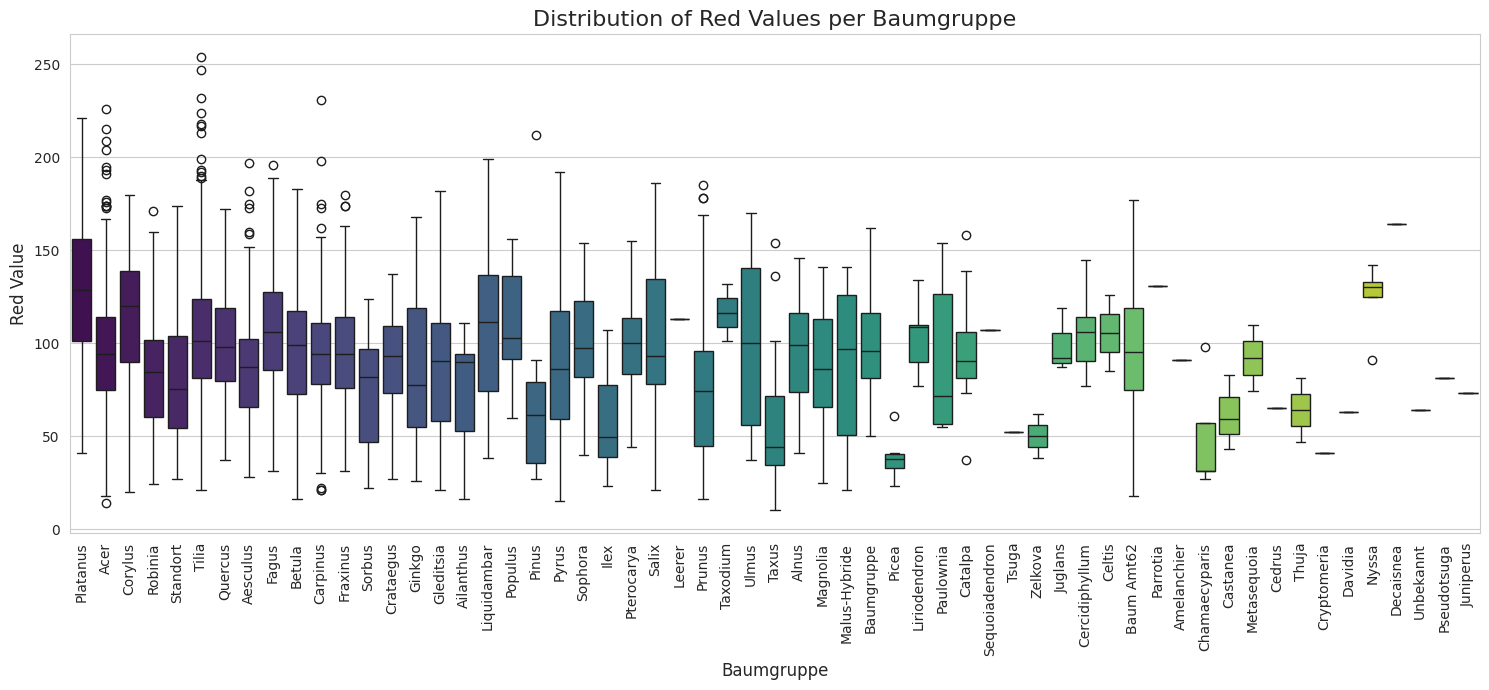

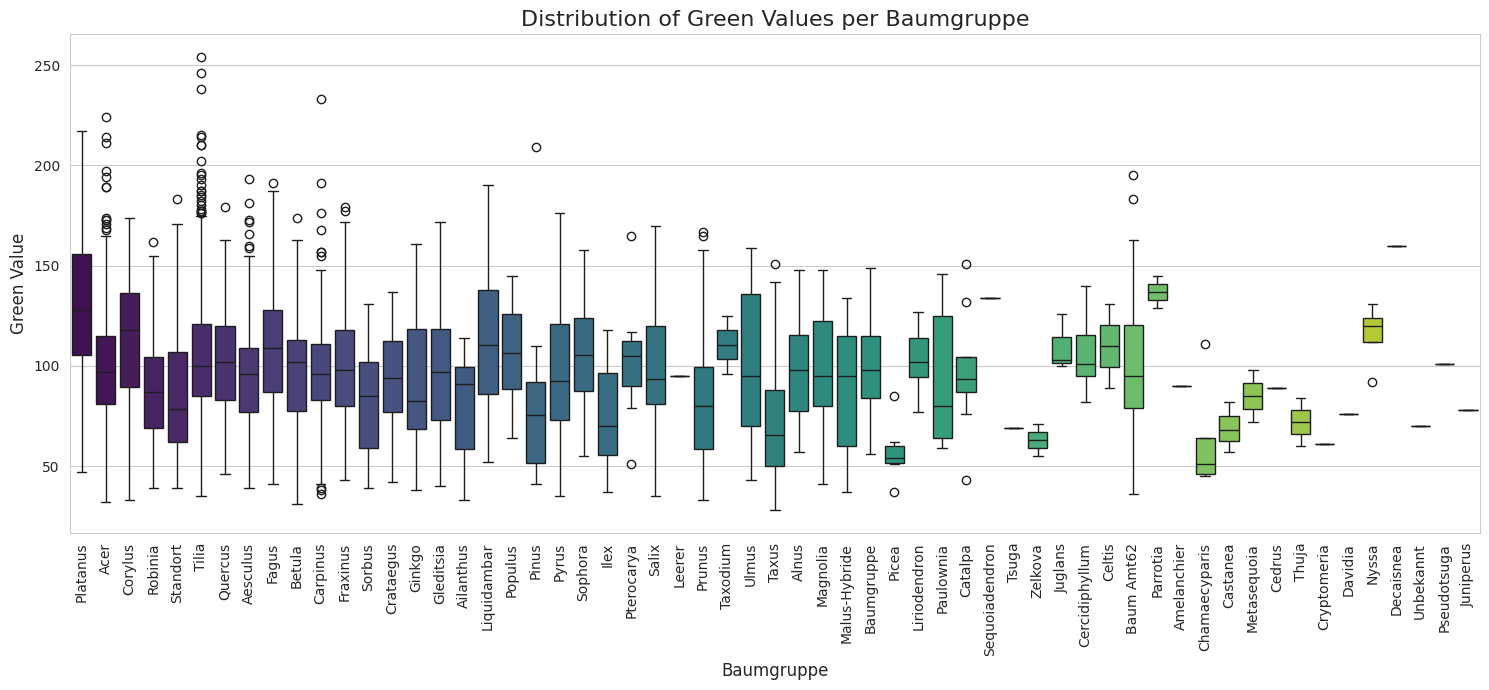

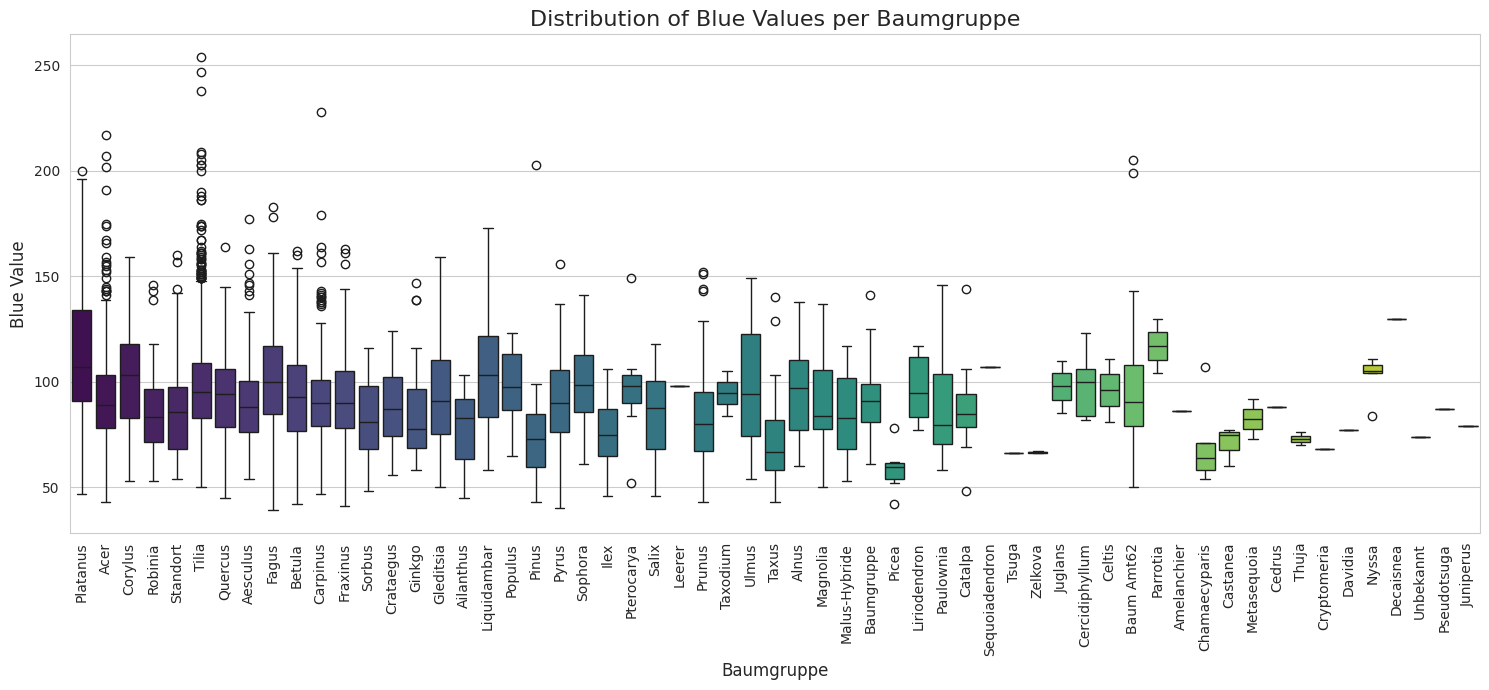

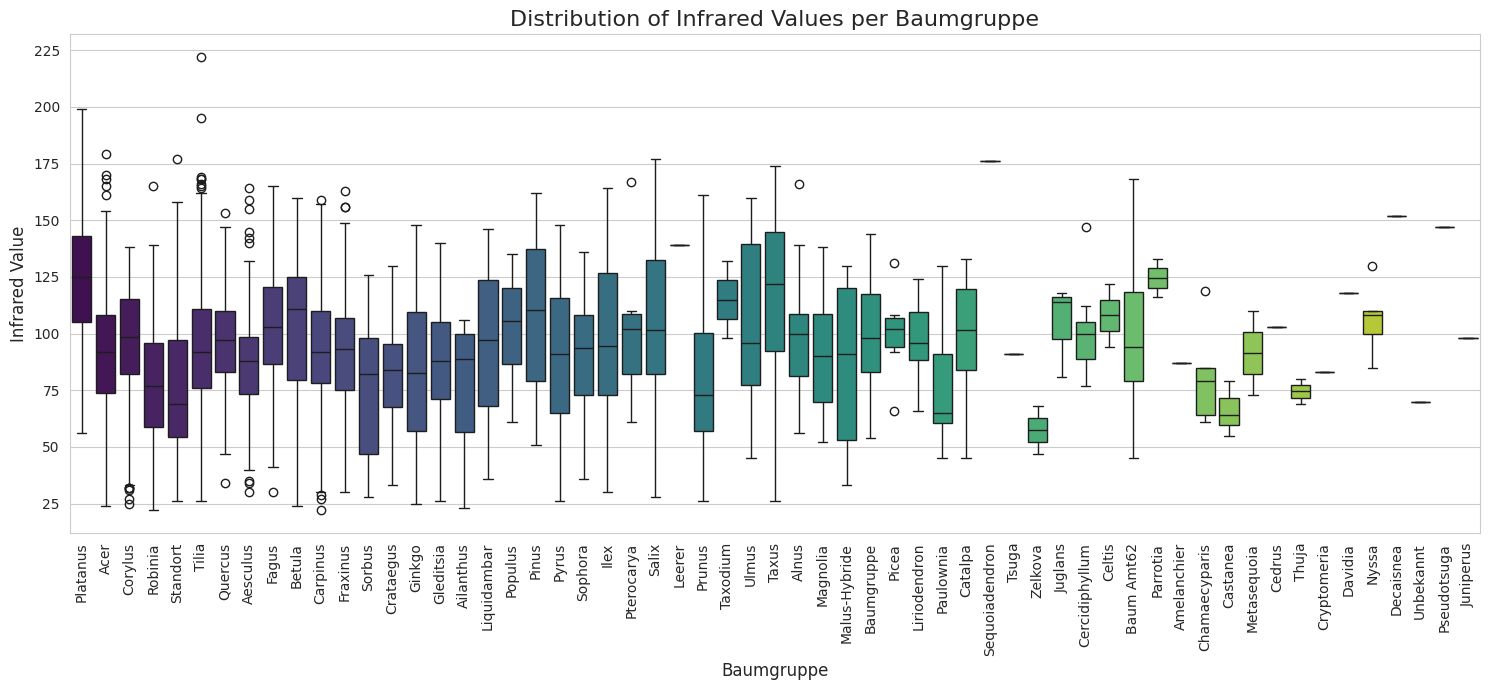

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for better aesthetics
sns.set_style("whitegrid")

# Define the color columns to plot
color_columns = ['pixel_red', 'pixel_green', 'pixel_blue', 'pixel_infrared']

# Use the filtered DataFrame: pixel_df_filtered
for col in color_columns:
    plt.figure(figsize=(15, 7))
    # Updated for FutureWarning: Assign x to hue and set legend=False
    sns.boxplot(x='baumgruppe', y=col, data=pixel_df_filtered, hue='baumgruppe', palette='viridis', legend=False)
    plt.title(f'Distribution of {col.replace("pixel_", "").replace("_", " ").title()} Values per Baumgruppe', fontsize=16)
    plt.xlabel('Baumgruppe', fontsize=12)
    plt.ylabel(f'{col.replace("pixel_", "").replace("_", " ").title()} Value', fontsize=12)
    plt.xticks(rotation=90) # Rotate x-axis labels for better readability if there are many groups
    plt.tight_layout() # Adjust layout to prevent labels from overlapping
    plt.show()

Now, let's filter the `pixel_df` to remove rows where all color values are zero, as these likely represent areas outside of the actual tree canopy or errors in sampling.

#### Version Flächendaten
Hier sollen rund um die punktuellen Baumkoordinaten definierten Flächen im rasterio-GeoTIFF eingezeichnet werden und das Baumlabel dieser Fläche und der entsprechenden Bildinformation zugeordnet werden.

In [ ]:
import rasterio
import pandas as pd
import numpy as np
from rasterio.windows import Window
import geopandas # Ensure geopandas is imported for gdf

# Define the directory where your GeoTIFF files are located (assuming drive_path is set)
# output_mosaic_path is assumed to be defined from the previous cell (e.g., 'merged_geotiff_mosaic.tif')

try:
    with rasterio.open(output_mosaic_path) as src_mosaic:
        # Ensure the GeoDataFrame (gdf) is available and reprojected to the mosaic's CRS
        # 'gdf' and 'gdf_projected' are expected to be defined from previous cells.
        # If not, attempt to load and reproject.
        if 'gdf' not in locals():
            print("gdf not found. Attempting to load 'gruen_opendata.geojson'.")
            geoj_file_path = '/content/drive/MyDrive/TechLabs_2026SoSe_DL/Daten/gruen_opendata.geojson'
            gdf = geopandas.read_file(geoj_file_path)
            if gdf.crs != src_mosaic.crs:
                gdf_projected = gdf.to_crs(src_mosaic.crs)
            else:
                gdf_projected = gdf.copy()
            print(f"Loaded and reprojected gdf from {gdf.crs} to {src_mosaic.crs}.")
        elif gdf.crs != src_mosaic.crs:
            gdf_projected = gdf.to_crs(src_mosaic.crs)
            print(f"Reprojected GeoDataFrame from {gdf.crs} to {src_mosaic.crs} for area sampling.")
        else:
            gdf_projected = gdf.copy()

        # Define the size of the square in meters (e.g., 10m x 10m)
        square_size_meters = 10
        # Calculate the size of the square in pixels
        # Resolution is 0.1m per pixel (10cm). src_mosaic.res[0] gives pixel width.
        pixel_resolution = src_mosaic.res[0]
        square_size_pixels = int(round(square_size_meters / pixel_resolution))

        if square_size_pixels <= 0:
             raise ValueError(f"Calculated square size in pixels is {square_size_pixels}. Check square_size_meters ({square_size_meters}) and pixel_resolution ({pixel_resolution}).")

        print(f"Defined square size: {square_size_meters}m x {square_size_meters}m, which corresponds to {square_size_pixels}x{square_size_pixels} pixels.")
        print(f"Number of bands in GeoTIFF: {src_mosaic.count}")

        # List to store processed data
        tree_areas_data = []

        # Iterate through each tree point in the projected GeoDataFrame
        for idx, row in gdf_projected.iterrows():
            point_geom = row.geometry
            baumgruppe_label = row['baumgruppe']

            # Get pixel coordinates for the center of the square
            # rasterio.index returns (row, col) for (x, y)
            col_center, row_center = src_mosaic.index(point_geom.x, point_geom.y)

            # Calculate the top-left pixel coordinates for a square of square_size_pixels
            half_pixel_size = square_size_pixels // 2
            col_off = col_center - half_pixel_size
            row_off = row_center - half_pixel_size

            # Create a window object for the desired square
            # Window takes (col_off, row_off, width, height)
            desired_window = Window(col_off, row_off, square_size_pixels, square_size_pixels)

            try:
                # Read the data, using boundless=True to fill areas outside the image with fill_value
                # This ensures all extracted arrays have the same target shape.
                pixel_data_extracted = src_mosaic.read(window=desired_window, boundless=True, fill_value=0)

                # pixel_data_extracted will have shape (bands, height, width)
                # Verify the shape is as expected after boundless read
                if pixel_data_extracted.shape[1] == square_size_pixels and \
                   pixel_data_extracted.shape[2] == square_size_pixels:

                    tree_areas_data.append({
                        'baumgruppe': baumgruppe_label,
                        'pixel_data': pixel_data_extracted, # Store the NumPy array directly
                        'point_coords_orig_crs': (row.geometry.x, row.geometry.y), # Store original point coords
                        'point_coords_proj_crs': (point_geom.x, point_geom.y),
                        'center_pixel_coords': (col_center, row_center),
                        'window_top_left_pixel_offset': (col_off, row_off)
                    })

            except Exception as read_error:
                print(f"Error reading window for tree {idx}: {read_error}. Skipping.")
                continue

        print(f"Successfully processed {len(tree_areas_data)} tree areas.")

        # Convert the list of dictionaries to a DataFrame
        tree_areas_df = pd.DataFrame(tree_areas_data)

        print("\nHead of the prepared tree areas dataset (first 5 rows):")
        display(tree_areas_df.head())
        print("\nInformation about the prepared tree areas dataset:")
        tree_areas_df.info()

except rasterio.errors.RasterioIOError as e:
    print(f"Error opening or reading GeoTIFF file: {e}")
    print("Please ensure 'merged_geotiff_mosaic.tif' exists at the specified path and is a valid GeoTIFF.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

An unexpected error occurred: name 'output_mosaic_path' is not defined
